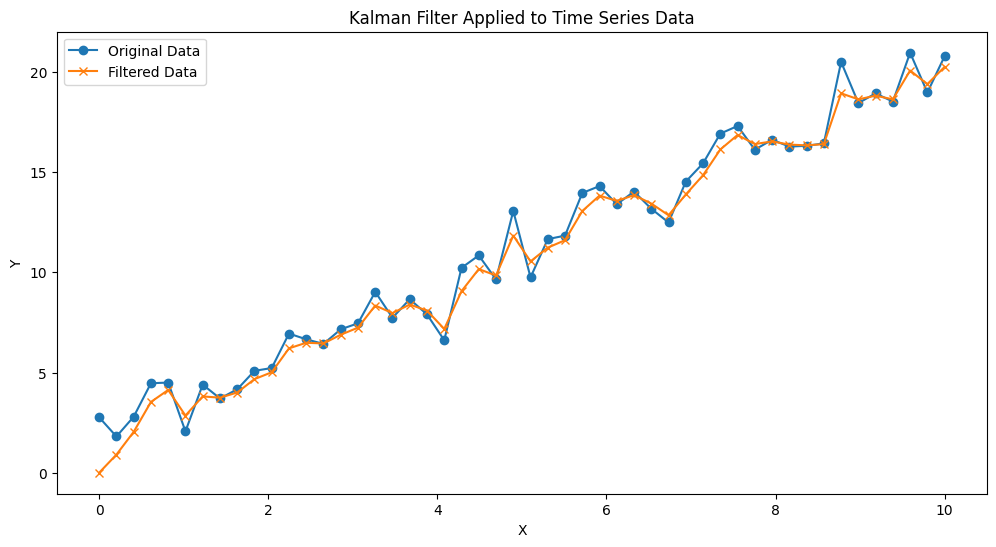

In [1]:
# Section 1: Understanding the principles of Kalman Filters

import numpy as np
import matplotlib.pyplot as plt
# Generate data for simulation
np.random.seed(0)
n = 50
x = np.linspace(0, 10, n)
y = 2*x + 1 + np.random.normal(0, 1, n)
# Kalman Filter implementation
def kalman_filter(data, Q=0.1, R=0.1):
    n = len(data)
    x_hat = np.zeros(n)    # Predicted state estimate
    P = np.zeros(n)        # Predicted error covariance
    x_hat_minus = np.zeros(n)
    P_minus = np.zeros(n)
    for k in range(1, n):
        # Time update
        x_hat_minus[k] = x_hat[k-1]
        P_minus[k] = P[k-1] + Q
        # Measurement update
        K = P_minus[k] / (P_minus[k] + R)
        x_hat[k] = x_hat_minus[k] + K * (data[k] - x_hat_minus[k])
        P[k] = (1 - K) * P_minus[k]
    return x_hat
# Applying Kalman Filter to the generated data
filtered_data = kalman_filter(y)
# Plotting the original data and filtered data
plt.figure(figsize=(12, 6))
plt.plot(x, y, label='Original Data', marker='o')
plt.plot(x, filtered_data, label='Filtered Data', marker='x')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('Kalman Filter Applied to Time Series Data')
plt.show()

In [2]:
# Implementing Kalman Filters in Python for time series data

import yfinance as yf
# Downloading real-world financial data using yfinance library
ticker_1 = yf.Ticker("AAPL")
data_1 = ticker_1.history(start="2020-01-01", end="2024-04-30")['Close']
ticker_2 = yf.Ticker("MSFT")
data_2 = ticker_2.history(start="2020-01-01", end="2024-04-30")['Close']

Failed to get ticker 'AAPL' reason: Expecting value: line 1 column 1 (char 0)
AAPL: No timezone found, symbol may be delisted
Failed to get ticker 'MSFT' reason: Expecting value: line 1 column 1 (char 0)
MSFT: No timezone found, symbol may be delisted


In [3]:
# Kalman Filter implementation for pairs trading

import numpy as np
def kalman_filter_pairs(data_1, data_2, Q=0.1, R=0.1):
    n = len(data_1)
    spread = data_1 - data_2
    x_hat = np.zeros(n)    # Predicted state estimate
    P = np.zeros(n)        # Predicted error covariance
    x_hat_minus = np.zeros(n)
    P_minus = np.zeros(n)
    for k in range(1, n):
        # Time update
        x_hat_minus[k] = x_hat[k-1]
        P_minus[k] = P[k-1] + Q
        # Measurement update
        K = P_minus[k] / (P_minus[k] + R)
        x_hat[k] = x_hat_minus[k] + K * (spread[k] - x_hat_minus[k])
        P[k] = (1 - K) * P_minus[k]
    return x_hat
# Applying Kalman Filter to pairs trading data
filtered_spread = kalman_filter_pairs(data_1, data_2)

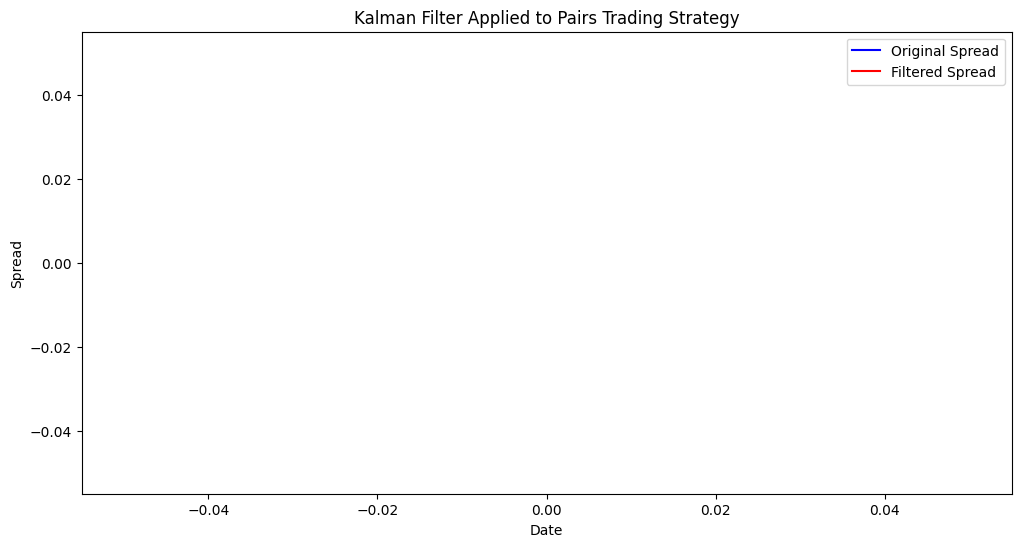

In [4]:
# Visualizing the original spread and filtered spread
plt.figure(figsize=(12, 6))
plt.plot(data_1.index, data_1.values - data_2.values,
         label='Original Spread', color='b')
plt.plot(data_1.index, filtered_spread, label='Filtered Spread', color='r')
plt.xlabel('Date')
plt.ylabel('Spread')
plt.legend()
plt.title('Kalman Filter Applied to Pairs Trading Strategy')
plt.show()